<a href="https://colab.research.google.com/github/nina96/trial/blob/main/MI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install transformer_lens

In [2]:
import transformer_lens
from transformer_lens import HookedTransformer
import torch

In [ ]:
model = HookedTransformer.from_pretrained("gpt2")

In [38]:
# A classic sentence from the IOI interpretability paper
prompt = "When John,Mary and Anna went to the store, John gave a bottle to"

In [39]:
# run_with_cache stores ALL intermediate activations
tokens = model.to_tokens(prompt)
logits, cache = model.run_with_cache(tokens)

In [40]:
# What does the model predict next?
top_token = logits[0, -1].argmax()
print(model.to_string(top_token))  # → " Mary"

 Anna


In [41]:
from transformer_lens.utils import get_act_name
import matplotlib.pyplot as plt

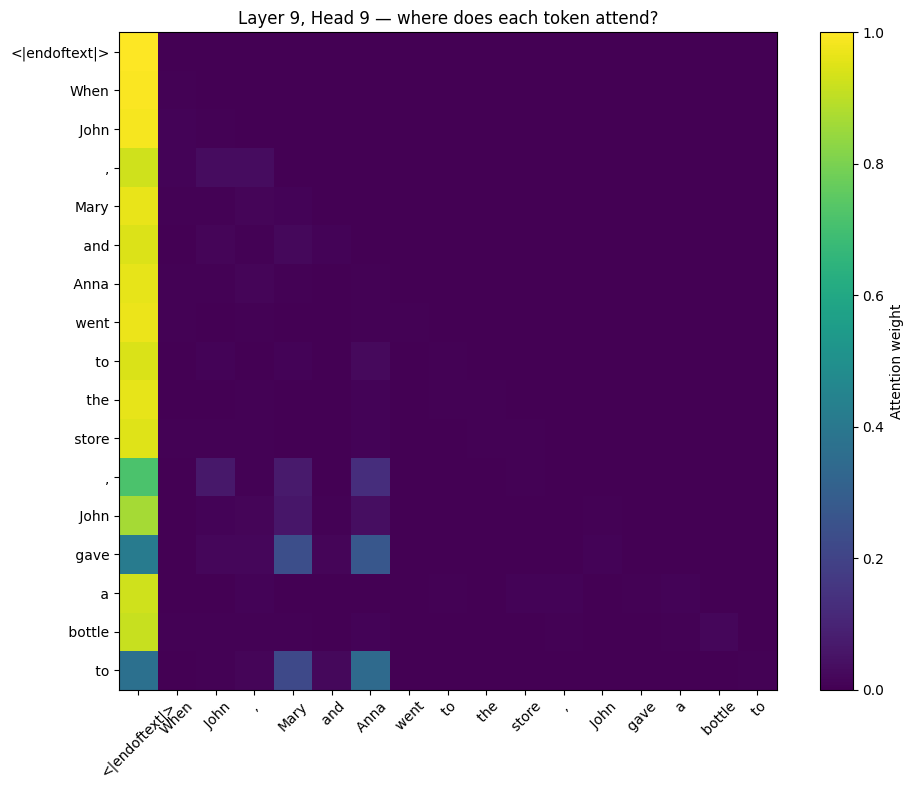

In [49]:
# Access attention pattern for Layer 9, Head 9
# This head is known to be important for the IOI task!
attn_pattern = cache["pattern", 10][0, 10]  # [batch, head, dest, src]

token_labels = model.to_str_tokens(prompt)

# Heatmap: rows = destination tokens, cols = source tokens
plt.figure(figsize=(10, 8))
plt.imshow(attn_pattern.detach().cpu().numpy(), cmap="viridis")
plt.xticks(range(len(token_labels)), token_labels, rotation=45)
plt.yticks(range(len(token_labels)), token_labels)
plt.colorbar(label="Attention weight")
plt.title("Layer 9, Head 9 — where does each token attend?")
plt.tight_layout()
plt.show()

In [44]:
mary_token = model.to_single_token(" Mary")
john_token = model.to_single_token(" John")
Anna_token= model.to_single_token(" Anna")

print(f"{'Layer':8} {'Mary logit':14} {'John logit':14} {'Anna Logit':14}Leading?")
print("-" * 60)

for layer in range(model.cfg.n_layers):
    # Get residual stream at this layer, last token position
    resid = cache["resid_post", layer][0, -1]

    # Apply final layer norm + unembed to project to vocab
    logits_here = model.ln_final(resid) @ model.W_U

    mary_l = logits_here[mary_token].item()
    john_l = logits_here[john_token].item()
    anna_l = logits_here[Anna_token].item()

    if john_l >= mary_l and john_l >= anna_l:
        leader = "✅ J"
    elif mary_l >= john_l and mary_l >= anna_l:
        leader = "✅ M"
    else:
        leader = "✅ A"

    print(f"Layer {layer:2}  Mary={mary_l:6.2f}       John={john_l:6.2f}    Anna={anna_l:6.2f}    {leader}")

Layer    Mary logit     John logit     Anna Logit    Leading?
------------------------------------------------------------
Layer  0  Mary=  2.13       John=  2.20    Anna=  2.08    ✅ J
Layer  1  Mary=  2.74       John=  2.72    Anna=  2.59    ✅ M
Layer  2  Mary=  4.38       John=  4.31    Anna=  2.04    ✅ M
Layer  3  Mary=  4.34       John=  3.66    Anna=  2.71    ✅ M
Layer  4  Mary=  3.63       John=  3.36    Anna=  2.66    ✅ M
Layer  5  Mary=  5.56       John=  5.76    Anna=  3.92    ✅ J
Layer  6  Mary=  5.54       John=  5.93    Anna=  5.52    ✅ J
Layer  7  Mary=  9.42       John=  6.19    Anna=  9.49    ✅ A
Layer  8  Mary= 16.82       John= 12.42    Anna= 14.00    ✅ M
Layer  9  Mary= 23.35       John= 13.67    Anna= 31.35    ✅ A
Layer 10  Mary= 23.92       John= 13.02    Anna= 29.73    ✅ A
Layer 11  Mary= 13.81       John= 10.30    Anna= 15.97    ✅ A


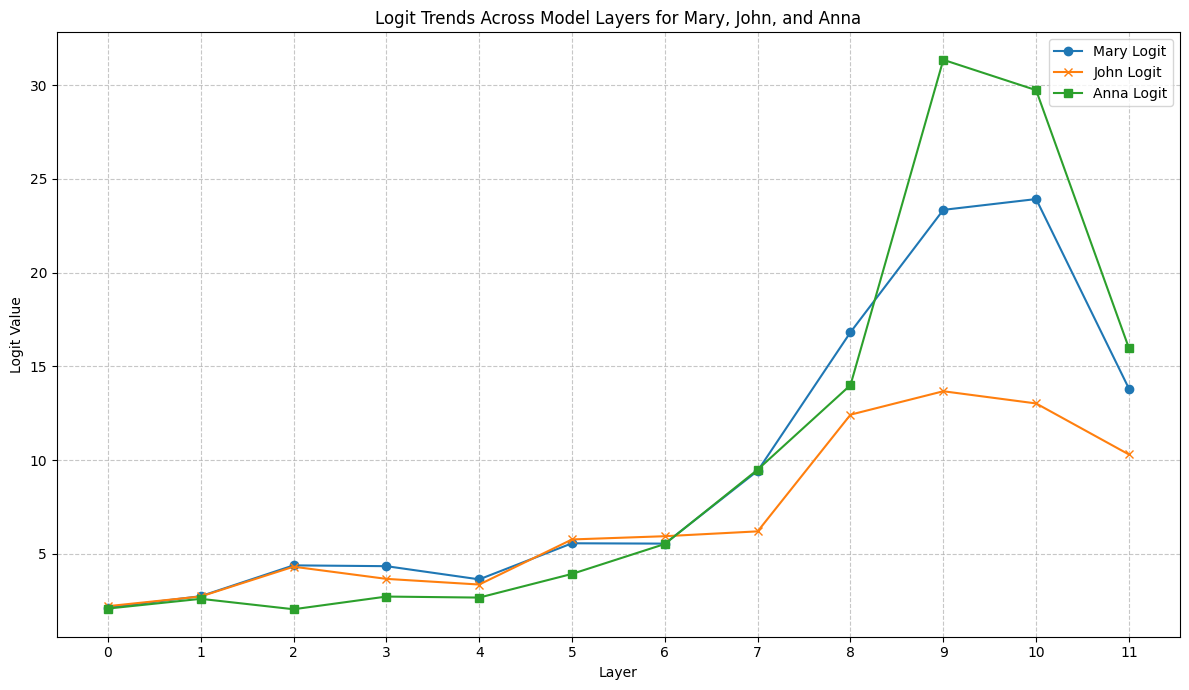

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data for plotting
logit_trends = []
for layer in range(model.cfg.n_layers):
    resid = cache["resid_post", layer][0, -1]
    logits_here = model.ln_final(resid) @ model.W_U

    mary_l = logits_here[mary_token].item()
    john_l = logits_here[john_token].item()
    anna_l = logits_here[Anna_token].item()
    logit_trends.append({
        'Layer': layer,
        'Mary': mary_l,
        'John': john_l,
        'Anna': anna_l
    })

logit_df = pd.DataFrame(logit_trends)

# Plotting the trends
plt.figure(figsize=(12, 7))
plt.plot(logit_df['Layer'], logit_df['Mary'], label='Mary Logit', marker='o')
plt.plot(logit_df['Layer'], logit_df['John'], label='John Logit', marker='x')
plt.plot(logit_df['Layer'], logit_df['Anna'], label='Anna Logit', marker='s')

plt.title('Logit Trends Across Model Layers for Mary, John, and Anna')
plt.xlabel('Layer')
plt.ylabel('Logit Value')
plt.xticks(range(model.cfg.n_layers))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
clean_prompt = "When John and Mary went to the store, John gave a bottle to"
clean_tokens = model.to_tokens(clean_prompt)
clean_logits, clean_cache = model.run_with_cache(clean_tokens)

In [59]:
patch_layer = 7  # Layer where Anna's logit started to dominate
hook_name = f"blocks.{patch_layer}.hook_resid_post"

def patch_resid_hook(activations, hook):
    # This hook replaces the residual stream activations at the last token position
    # of the corrupted run with the activations from the clean run.
    # activations: the activations of the corrupted run at this layer
    # hook: the hook object (contains metadata like layer index and name)

    # We need to make sure the token positions align. We are patching the last token.
    # Both prompts end with ' to', so we expect the last token's residual stream to be comparable.
    activations[0, -1] = clean_cache[hook.name][0, -1]
    return activations

# Run the corrupted prompt with the patching hook
patched_logits = model.run_with_hooks(tokens, fwd_hooks=[(hook_name, patch_resid_hook)])

### Logit Comparison After Patching Layer 7

Now, let's compare the logits for "Mary", "John", and "Anna" after patching the residual stream at Layer 7 of the corrupted run with the values from the clean run.

In [60]:
mary_token = model.to_single_token(" Mary")
john_token = model.to_single_token(" John")
Anna_token = model.to_single_token(" Anna")

# Get logits from the patched run
patched_logits_last_token = patched_logits[0, -1]

mary_l_patched = patched_logits_last_token[mary_token].item()
john_l_patched = patched_logits_last_token[john_token].item()
anna_l_patched = patched_logits_last_token[Anna_token].item()

print(f"Logits after patching Layer {patch_layer}:")
print(f"  Mary: {mary_l_patched:.2f}")
print(f"  John: {john_l_patched:.2f}")
print(f"  Anna: {anna_l_patched:.2f}")

# Determine the leading name after patching
if john_l_patched >= mary_l_patched and john_l_patched >= anna_l_patched:
    leader_patched = "John"
elif mary_l_patched >= john_l_patched and mary_l_patched >= anna_l_patched:
    leader_patched = "Mary"
else:
    leader_patched = "Anna"

print(f"Leading name after patching: {leader_patched}")

# You can also compare with the original logits from PEAlplbHjX99 (Layer 7):
# Original Layer 7:   Mary=  9.42       John=  6.19    Anna=  9.49    ✅ A
# Note: `cache` is from the original `run_with_cache` for the 'corrupted' prompt
print(f"\nOriginal logits at Layer {patch_layer} for comparison (from previous run):")
original_resid_layer7 = cache["resid_post", patch_layer][0, -1]
original_logits_layer7 = model.ln_final(original_resid_layer7) @ model.W_U

print(f"  Mary (original L{patch_layer}): {original_logits_layer7[mary_token].item():.2f}")
print(f"  John (original L{patch_layer}): {original_logits_layer7[john_token].item():.2f}")
print(f"  Anna (original L{patch_layer}): {original_logits_layer7[Anna_token].item():.2f}")

Logits after patching Layer 7:
  Mary: 15.65
  John: 13.46
  Anna: 16.93
Leading name after patching: Anna

Original logits at Layer 7 for comparison (from previous run):
  Mary (original L7): 9.42
  John (original L7): 6.19
  Anna (original L7): 9.49
